# Practical 01 — Python Foundations for Machine Learning

**Laboratory:** M.Tech Machine Learning  
**Experiment:** NumPy, Pandas, Matplotlib/Seaborn, scikit-learn  
**How to use this notebook:** start at the **Colab header**, then the **DATASET CONFIG** cell. You only edit the config cell to swap a CSV.

### Lab map

```text
[1] Colab / packages  →  [2] DATASET CONFIG (your CSV)  →  [3] Load & preview
         ↓
[4] NumPy (fast arrays)  →  [5] Pandas (tables)  →  [6] Plots (EDA)
         ↓
[7] Split → impute/scale on TRAIN only → LinearRegression → test metrics
         ↓
[8] Viva Q&A  →  [9] Conclusion
```

### Learning outcomes (plain English)

1. Use **NumPy** so numeric work runs on whole arrays, not Python `for` loops.
2. Understand **broadcasting**: one row of means can clean a whole table of columns.
3. Point this notebook at **your own CSV** with three variables (`DATA_PATH`, `TARGET_COLUMN`, `DROP_COLUMNS`).
4. Inspect, filter, and `groupby` a table with **Pandas**.
5. Draw **clear EDA plots** (histogram, boxplot, scatter, heatmap).
6. Fit a **fair** linear baseline: split first, then scale using **training** statistics only.

> **Why this matters:** every later ML lab reuses this loop. If the CSV path, target column, or train-only scaling is wrong, metrics lie.

### Mathematical framing (renders in Jupyter / Colab)

A supervised regression dataset is a pair $(X, y)$ with design matrix $X \in \mathbb{R}^{n \times p}$ ( $n$ rows, $p$ features) and target $y \in \mathbb{R}^{n}$. A linear predictor is

$$
\hat{y} = Xw + b\mathbf{1}
$$

where $w \in \mathbb{R}^{p}$ and $b \in \mathbb{R}$. We fit on a **training** subset and always score a disjoint **test** subset so we measure generalization, not memorization.


## Colab 1-click header (skip the upload bits on a campus PC)

**Google Colab**

1. Runtime → Run all (or run this cell, then the config cell).
2. If you brought your own CSV: when prompted, **upload** it, **or** mount Drive and set `COLAB_DRIVE_CSV` in the config cell.
3. If you have no file: the loader uses a public URL, then sklearn as last resort.

**Local Jupyter (this lab machine)**  
This cell only prints environment info. Packages should already be in `ml-lab-kernel`.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, Markdown, display

def _banner(text: str, bg: str = "#0f766e") -> None:
    '''Bright section label so lab outputs are easy to find in a long notebook.'''
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f'border-radius:8px;font-family:Segoe UI,sans-serif;'
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _note(text: str, bg: str = "#ecfeff") -> None:
    display(
        HTML(
            f'<div style="background:{bg};border-left:4px solid #0e7490;'
            f'padding:10px 14px;border-radius:4px;font-family:Segoe UI,sans-serif;'
            f'margin:6px 0;">{text}</div>'
        )
    )


IN_COLAB = "google.colab" in sys.modules
_banner("0 · Runtime", "#134e4a")
_note(
    f"<b>Colab detected:</b> {IN_COLAB} &nbsp;|&nbsp; <b>Python</b> {sys.version.split()[0]}"
)

if IN_COLAB:
    # Magic form (Colab / IPython). Equivalent: %pip install -q numpy pandas matplotlib seaborn scikit-learn
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )
    _note("Packages installed (or already present) in this Colab runtime.")
else:
    _note("Local kernel: skipping %pip. Use the lab venv / ml-lab-kernel.")


def colab_upload_to(dest: Path) -> Path | None:
    '''1-click CSV upload on Colab. Returns saved path, or None if not Colab / cancelled.'''
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    _note("Choose a <b>.csv</b> in the file picker (your dataset).")
    uploaded = files.upload()  # why: Colab has no ./data folder until you add one
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    _note(f"Saved upload to <code>{dest}</code>")
    return dest


def colab_mount_drive() -> Path | None:
    '''Mount Google Drive (Colab only). Returns /content/drive/MyDrive if successful.'''
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")  # why: reuse a CSV you already stored in Drive
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None

def _rule(title: str = "") -> None:
    """Visual divider so successive print blocks are easy to scan."""
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


## 0. Environment, seeds, and plotting defaults

> **Why this matters:** one **seed** makes numbers match your lab partner. Pinning **dpi** once makes every figure readable in a PDF lab record.


In [20]:
import timeit
from typing import Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

SEED = 42  # why: any fixed integer is fine; 42 is a common lab convention
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (14, 7),   # why: large on-screen figures for lab projection / PDF
    "figure.dpi": 140,           # why: high-DPI rendering (sharp saved outputs)
    "savefig.dpi": 300,          # why: print-quality exports
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pd.set_option("display.max_columns", 25)  # why: wide tables stay readable in the output pane
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 40)
sns.set_theme(style="whitegrid", palette="colorblind")  # why: colorblind-safer default hues

_banner("0 · Libraries", "#155e75")
print(f"Python {sys.version.split()[0]}")
print(f"numpy {np.__version__}  |  pandas {pd.__version__}  |  sklearn (LinearRegression + SimpleImputer)")
print(f"SEED = {SEED}")


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


Python 3.14.0
numpy 2.5.2  |  pandas 3.0.5  |  sklearn (LinearRegression + SimpleImputer)
SEED = 42


## DATASET CONFIG BLOCK — the only cell most beginners need to edit

```text
  Your CSV on disk          What to predict           Ignore (IDs, names, ...)
  DATA_PATH  ────────────►  TARGET_COLUMN  ────────►  DROP_COLUMNS
       │                         │
       │                         └── must match a header name exactly
       └── relative to this notebook, e.g. data/my_file.csv
```

**Lab default (already filled in):** 400-row housing-style table next to this notebook.

**Use your own data:** change the three assignments below. First row of the CSV must be column names.

> **Why this matters:** ML code does not “know” which column is the answer. You name the target. Wrong name → wrong experiment.


In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — edit this block to swap your own CSV               ║
# ╚══════════════════════════════════════════════════════════════════════╝

# 1) Path to the table (relative to this notebook on a PC).
DATA_PATH = "data/california_housing_lab_benchmark.csv"

# 2) Column you want to PREDICT (must match the header exactly).
TARGET_COLUMN = "median_house_value"

# 3) Columns to drop (IDs, free text, leakage columns you are not using yet).
DROP_COLUMNS: list[str] = []  # example: ["id", "address"]

# 4) Optional EDA helper (income-like column). Set None if your CSV has none.
INCOME_COLUMN: str | None = "median_income"

# Colab-only extras (ignored locally):
COLAB_DRIVE_CSV: str | None = None  # e.g. "/content/drive/MyDrive/my_data.csv"
COLAB_OFFER_UPLOAD = True           # if local file missing on Colab, open the picker

HOUSING_URL = (
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
    "datasets/housing/housing.csv"
)  # why: public copy so Colab works with zero files uploaded

LoadOrigin = Literal["local", "colab_upload", "gdrive", "url", "sklearn"]


def _from_sklearn_housing() -> pd.DataFrame:
    bunch = fetch_california_housing(as_frame=True)  # why: last-resort offline-ish data
    frame = bunch.frame.copy()
    return frame.rename(columns={"MedHouseVal": "median_house_value"})


def load_configured_table() -> tuple[pd.DataFrame, LoadOrigin]:
    path = Path(DATA_PATH)

    if path.is_file():
        return pd.read_csv(path), "local"

    if IN_COLAB and COLAB_DRIVE_CSV:
        colab_mount_drive()
        drive_path = Path(COLAB_DRIVE_CSV)
        if drive_path.is_file():
            return pd.read_csv(drive_path), "gdrive"

    if IN_COLAB and COLAB_OFFER_UPLOAD:
        saved = colab_upload_to(path)
        if saved is not None and saved.is_file():
            return pd.read_csv(saved), "colab_upload"

    try:
        return pd.read_csv(HOUSING_URL), "url"
    except Exception as url_exc:
        _note(f"URL fallback failed: {type(url_exc).__name__}: {url_exc}", bg="#fef3c7")
        return _from_sklearn_housing(), "sklearn"


df, load_origin = load_configured_table()

for col in DROP_COLUMNS:
    if col in df.columns:
        df = df.drop(columns=[col])  # why: IDs do not belong in a naive numeric model

_banner("CONFIG · Load result", "#1d4ed8")
print(f"load_origin     = {load_origin}")
print(f"DATA_PATH       = {DATA_PATH}")
print(f"shape           = {df.shape[0]} rows × {df.shape[1]} columns")
print(f"columns         = {list(df.columns)}")

if TARGET_COLUMN not in df.columns:
    display(
        HTML(
            '<div style="background:#7f1d1d;color:#fff;padding:12px;border-radius:8px;">'
            f"<b>TARGET_COLUMN={TARGET_COLUMN!r} is not in this CSV.</b><br>"
            "Fix the name in the CONFIG block. Columns are listed above."
            "</div>"
        )
    )
    raise KeyError(f"TARGET_COLUMN {TARGET_COLUMN!r} not in {list(df.columns)}")

_note(
    f"Target <code>{TARGET_COLUMN}</code> found. "
    "Missing target values will be dropped later (we do not impute the label)."
)

_num_preview = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
styled_head = (
    df.head(8)
    .style.set_caption("First 8 rows (sanity check: headers and types look right?)")
    .format(precision=3)
    .background_gradient(subset=_num_preview, cmap="Blues")
)
display(styled_head)


load_origin     = local
DATA_PATH       = data/california_housing_lab_benchmark.csv
shape           = 400 rows × 10 columns
columns         = ['median_income', 'house_age', 'avg_rooms', 'avg_bedrooms', 'population', 'avg_occupancy', 'latitude', 'longitude', 'ocean_proximity', 'median_house_value']


,median_income,house_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,ocean_proximity,median_house_value
0,4.688,24,3.583,1.067,2643,2.212,36.460,-121.075,NEAR OCEAN,255050.590
1,2.536,8,3.991,0.920,3553,2.636,33.443,-117.327,<1H OCEAN,165384.840
2,5.401,44,4.934,1.294,3315,1.891,39.858,-114.730,<1H OCEAN,327199.940
3,5.705,40,4.827,1.419,2118,1.872,41.359,-118.425,<1H OCEAN,348785.390
4,1.078,42,6.294,1.585,1032,2.861,32.709,-117.657,INLAND,175986.560
5,2.116,11,5.666,1.878,4201,2.416,38.153,-119.929,INLAND,174141.100
6,4.404,1,3.447,0.806,3791,3.302,39.680,-116.739,NEAR BAY,226186.300
7,3.694,47,5.967,1.667,2832,3.362,35.177,-114.323,<1H OCEAN,280717.710


## 1. NumPy — arrays, vectorization, and why loops lose

### 1.1 A picture of an array

```text
Python list:  [ 1.0 | 2.0 | 3.0 ]   each box is a Python object (slow to add in a loop)

NumPy ndarray (length n):
  ┌─────┬─────┬─────┬─────┐
  │ a0  │ a1  │ a2  │ …   │   one typed block; + and @ run in compiled code
  └─────┴─────┴─────┴─────┘
```

The **dot product** of $a, b \in \mathbb{R}^{n}$ is

$$
a^{\top} b = \sum_{i=1}^{n} a_i b_i
$$

> **Why this matters:** ML is mostly “multiply and add a lot of numbers.” Vectorization is how we do that in seconds, not minutes.


In [4]:
def python_dot(a: np.ndarray, b: np.ndarray) -> float:
    '''Pedagogical (slow) inner product - do not use in production kernels.'''
    total = 0.0
    for i in range(a.shape[0]):  # why: each i pays Python bytecode cost
        total += float(a[i] * b[i])
    return total


n_demo = 200_000  # why: large enough that timing differences are obvious
a = np.random.randn(n_demo)
b = np.random.randn(n_demo)

_banner("1.1 · Vectorized vs Python loop", "#7c3aed")

# %time: one-run wall clock (IPython magic requested for the lab record)
print("One-shot %time (includes a little overhead):")
get_ipython().run_line_magic("time", "_ = python_dot(a, b)")
get_ipython().run_line_magic("time", "_ = float(a @ b)")

n_rounds = 8  # why: average a few runs so one noisy timing does not mislead
t_loop = timeit.timeit(lambda: python_dot(a, b), number=n_rounds) / n_rounds
t_vec = timeit.timeit(lambda: float(a @ b), number=n_rounds) / n_rounds
speedup = t_loop / max(t_vec, 1e-12)

dot_vec = float(a @ b)
dot_loop = python_dot(a, b)
rel_err = abs(dot_vec - dot_loop) / (abs(dot_vec) + 1e-12)

display(
    HTML(
        "<table style='font-family:Segoe UI,sans-serif;border-collapse:collapse'>"
        "<tr style='background:#1e1b4b;color:#fff'><th style='padding:8px'>Method</th>"
        "<th style='padding:8px'>Mean seconds</th><th style='padding:8px'>Notes</th></tr>"
        f"<tr style='background:#fee2e2'><td style='padding:8px'>Python for-loop</td>"
        f"<td style='padding:8px'><b>{t_loop:.4f}</b></td><td style='padding:8px'>n = {n_demo:,}</td></tr>"
        f"<tr style='background:#dcfce7'><td style='padding:8px'>NumPy a @ b</td>"
        f"<td style='padding:8px'><b>{t_vec:.6f}</b></td>"
        f"<td style='padding:8px'>speedup ≈ <b>{speedup:.0f}×</b></td></tr>"
        "</table>"
    )
)
print(f"vectorized a @ b = {dot_vec:.6f}")
print(f"Python loop       = {dot_loop:.6f}")
print(f"relative gap      = {rel_err:.2e}  (numerical rounding, not a different formula)")


One-shot %time (includes a little overhead):
CPU times: total: 31.2 ms
Wall time: 34.4 ms
CPU times: total: 0 ns
Wall time: 530 μs


Method,Mean seconds,Notes
Python for-loop,0.0333,"n = 200,000"
NumPy a @ b,0.000153,speedup ≈ 218×


vectorized a @ b = -199.227372
Python loop       = -199.227372
relative gap      = 1.23e-14  (numerical rounding, not a different formula)


### 1.2 Linear algebra used constantly in ML

Matrix–vector product $Xw$ with $X \in \mathbb{R}^{n \times p}$, $w \in \mathbb{R}^{p}$:

$$
(Xw)_i = \sum_{j=1}^{p} X_{ij} w_j
$$

**Ordinary least squares** (when $X^{\top}X$ is invertible) has the closed form

$$
\hat{w}_{\mathrm{OLS}} = (X^{\top} X)^{-1} X^{\top} y
$$

```text
  Features X (n × p)     weights w          prediction
  [ house features ]  ×  [ w1, w2, … ]  =  [ ŷ for each row ]
```

> **Why this matters:** sklearn’s `LinearRegression` solves this idea with a stable method (QR / SVD), **not** by blindly calling “invert this matrix” on messy real data. We still show `np.linalg.solve` on a **tiny well-conditioned** toy so the formula is concrete.


In [5]:
rng = np.random.default_rng(SEED)  # why: isolated RNG so this toy does not steal np.random state
X_toy = rng.normal(size=(8, 3))    # why: 8 samples, 3 features — small enough to print
Phi = np.column_stack([np.ones(8), X_toy])  # why: extra column of 1s = intercept b
w_true = np.array([1.5, -0.8, 0.4, 2.0])
y_toy = Phi @ w_true + rng.normal(scale=0.05, size=8)  # why: tiny noise so recovery is not exact

A = Phi.T @ Phi          # Gram matrix ΦᵀΦ
rhs = Phi.T @ y_toy      # Φᵀy
w_hat = np.linalg.solve(A, rhs)  # why: solve Aw=rhs; more stable than inv(A) @ rhs

_banner("1.2 · Toy OLS", "#6d28d9")
print("Phi shape", Phi.shape, "| rank", np.linalg.matrix_rank(Phi))
coef_cmp = pd.DataFrame({"w_true": w_true, "w_hat": w_hat, "abs_err": np.abs(w_hat - w_true)})
display(coef_cmp.style.format(precision=4).background_gradient(subset=["abs_err"], cmap="OrRd").set_caption("True vs recovered weights"))
print("||w_hat - w_true||_2 =", float(np.linalg.norm(w_hat - w_true)))


Phi shape (8, 4) | rank 4


,w_true,w_hat,abs_err
0,1.5000,1.5157,0.0157
1,-0.8000,-0.7511,0.0489
2,0.4000,0.4324,0.0324
3,2.0000,1.9916,0.0084


||w_hat - w_true||_2 = 0.061321190572444


### 1.3 Broadcasting (the rule that replaces tiled copies)

```text
X  shape (6, 4)     minus     mu shape (4,)
row0:  x00 x01 x02 x03                 μ0  μ1  μ2  μ3
row1:  x10 x11 x12 x13         →      same μ subtracted from EVERY row
...

NumPy pretends mu is (1, 4) and stretches it down 6 rows — no Python loop.
```

Rules (simplified):

1. Align shapes **on the right**.
2. Dimensions match if they are equal **or** one of them is $1$.
3. Output size on each axis is the **max** of the two sizes.

Column standardization of $X \in \mathbb{R}^{n \times p}$:

$$
Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}, \quad \mu, \sigma \in \mathbb{R}^{p}
$$

> **Why this matters:** `StandardScaler` is this idea, with $\mu$ and $\sigma$ learned from **train** rows only (later in the notebook).


In [6]:
X_bc = rng.normal(loc=10.0, scale=3.0, size=(6, 4))  # why: loc/scale make raw means obviously ≠ 0
mu = X_bc.mean(axis=0)  # why: axis=0 = “down the rows” → one statistic per column
sigma = X_bc.std(axis=0, ddof=0)  # why: ddof=0 is population std; sklearn StandardScaler uses this
Z = (X_bc - mu) / sigma  # broadcasting: (6,4) - (4,) → (6,4)

_banner("1.3 · Broadcasting / column z-score", "#5b21b6")
print("X_bc shape", X_bc.shape, "| mu shape", mu.shape)
print("Z column means ~ 0:", np.round(Z.mean(axis=0), 12))
print("Z column stds  ~ 1:", np.round(Z.std(axis=0), 12))

# Outer-sum pattern: stand u up as a column, v as a row
u = np.arange(4)
v = np.array([10, 20, 30])
pairwise = u[:, None] + v[None, :]  # why: None inserts a size-1 axis for broadcasting
print("pairwise sums shape", pairwise.shape)
print(pairwise)


X_bc shape (6, 4) | mu shape (4,)
Z column means ~ 0: [-0.  0.  0.  0.]
Z column stds  ~ 1: [1. 1. 1. 1.]
pairwise sums shape (4, 3)
[[10 20 30]
 [11 21 31]
 [12 22 32]
 [13 23 33]]


### 1.4 Norms and cosine similarity

$$
\|x\|_2 = \sqrt{x^{\top}x}, \qquad
\cos\theta = \frac{x^{\top} z}{\|x\|_2 \|z\|_2}
$$

```text
Two arrows in a plane:  cosine = 1 if they point the same way, 0 if they are at right angles.
After we ℓ₂-normalize each row, the Gram matrix G = F Fᵀ stores those cosines.
Diagonal of G must be ~ 1 (a vector compared with itself).
```

> **Why this matters:** k-NN and embeddings compare rows with this geometry. Here we only check the identity on a tiny matrix.


In [7]:
F = rng.normal(size=(5, 8))  # why: 5 vectors in R^8
row_norms = np.linalg.norm(F, axis=1, keepdims=True)  # why: keepdims=(5,1) so we can divide F (5,8)
F_unit = F / row_norms
G = F_unit @ F_unit.T  # G_ij = cosine(i, j)

_banner("1.4 · Cosine Gram matrix", "#4c1d95")
g_style = (
    pd.DataFrame(G, columns=[f"v{j}" for j in range(5)], index=[f"v{i}" for i in range(5)])
    .style.format("{:.3f}")
    .background_gradient(cmap="vlag", vmin=-1, vmax=1)
    .set_caption("Cosine Gram (diagonal should be ~ 1)")
)
display(g_style)
assert np.allclose(np.diag(G), 1.0, atol=1e-10)


,v0,v1,v2,v3,v4
v0,1.000,-0.229,0.521,0.134,-0.078
v1,-0.229,1.000,-0.429,-0.113,0.710
v2,0.521,-0.429,1.000,-0.305,-0.171
v3,0.134,-0.113,-0.305,1.000,0.234
v4,-0.078,0.710,-0.171,0.234,1.000


## 3. Pandas — inspection, types, filtering, aggregation

### 3.1 Schema and quality snapshot

```text
Spreadsheet view:
  rows    = examples (houses, students, days, …)
  columns = fields (income, age, price, …)
  empty   = missing (NaN) — scalers and linear models dislike surprise NaNs
```

> **Why this matters:** ML bugs are often silent: an `object` column that looks numeric, or NaNs that crash `StandardScaler`.


In [8]:
def schema_report(frame: pd.DataFrame) -> pd.DataFrame:
    n = len(frame)
    rows = []
    for col in frame.columns:
        s = frame[col]
        rows.append(
            {
                "column": col,
                "dtype": str(s.dtype),
                "non_null": int(s.notna().sum()),
                "missing_pct": 100.0 * float(s.isna().mean()),
                "nunique": int(s.nunique(dropna=True)),
            }
        )
    return pd.DataFrame(rows)


_banner("3.1 · Schema", "#0369a1")
schema_tbl = schema_report(df)
display(
    schema_tbl.style.format({"missing_pct": "{:.2f}"})
    .background_gradient(subset=["missing_pct"], cmap="YlOrRd")
    .set_caption("dtype, missingness, uniqueness — scan this before modeling")
)


,column,dtype,non_null,missing_pct,nunique
0,median_income,float64,400,0.00,398
1,house_age,int64,400,0.00,51
2,avg_rooms,float64,400,0.00,396
3,avg_bedrooms,float64,400,0.00,395
4,population,int64,400,0.00,377
5,avg_occupancy,float64,400,0.00,399
6,latitude,float64,400,0.00,398
7,longitude,float64,400,0.00,400
8,ocean_proximity,str,400,0.00,5
9,median_house_value,float64,400,0.00,400


In [9]:
_banner("3.1 · describe()", "#0284c7")
desc = df.describe(include="all").T.head(20)
_grad_cols = [c for c in ("mean", "std") if c in desc.columns]
_st = desc.style.format(precision=3).set_caption(
    "Classic EDA table (mean / std / percentiles). Transposed so each column is a row."
)
if _grad_cols:
    _st = _st.background_gradient(subset=_grad_cols, cmap="PuBu")
display(_st)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
median_income,400.000,nan,nan,nan,4.193,1.521,0.500,3.133,4.228,5.153,8.862
house_age,400.000,nan,nan,nan,26.462,14.570,1.000,14.000,27.000,39.000,51.000
avg_rooms,400.000,nan,nan,nan,5.342,1.120,1.500,4.616,5.402,6.040,8.897
avg_bedrooms,400.000,nan,nan,nan,1.332,0.405,0.500,1.039,1.294,1.607,2.476
population,400.000,nan,nan,nan,2378.613,1209.340,213.000,1235.000,2340.000,3441.000,4496.000
avg_occupancy,400.000,nan,nan,nan,2.881,0.792,1.000,2.375,2.891,3.406,5.331
latitude,400.000,nan,nan,nan,37.058,2.780,32.546,34.754,36.865,39.597,41.898
longitude,400.000,nan,nan,nan,-119.124,2.833,-124.273,-121.582,-119.014,-116.729,-114.318
ocean_proximity,400,5,<1H OCEAN,124,nan,nan,nan,nan,nan,nan,nan
median_house_value,400.000,nan,nan,nan,270740.411,64238.180,96601.220,224954.890,272613.040,314401.740,481579.250


### 3.2 Filtering (boolean masks) and `query`

```text
mask: keep row?   T  F  T  T  F
data:             r0 r1 r2 r3 r4
kept:             r0    r2 r3
```

Combine conditions with `&` / `|` and **parentheses**. Python `and` / `or` are **not** elementwise on a Series.

> **Why this matters:** EDA questions like “high income and known price” are filters, not new models.


In [10]:
target_col = TARGET_COLUMN  # why: single source of truth from the CONFIG block
income_col = INCOME_COLUMN if INCOME_COLUMN and INCOME_COLUMN in df.columns else None

_banner("3.2 · Filter", "#0e7490")
print("target_col =", target_col)
print("income_col =", income_col)

if income_col is not None:
    hi = df[(df[income_col] >= df[income_col].median()) & df[target_col].notna()]
    print("rows with income ≥ median and known target:", len(hi), "/", len(df))
    q = df.query(f"`{income_col}` >= `{income_col}`.median()")  # why: backticks allow odd column names
    print("query row count:", len(q))
else:
    print("No income column configured; skip income filter demo.")
    hi = df


target_col = median_house_value
income_col = median_income
rows with income ≥ median and known target: 200 / 400
query row count: 200


### 3.3 Aggregation: `groupby` and split–apply–combine

For a category $C$ and numeric $Y$:

$$
\bar{y}_c = \frac{1}{|\{i : C_i = c\}|} \sum_{i: C_i=c} y_i
$$

```text
Split by ocean_proximity → average house value in each group → one summary table
```

> **Why this matters:** group means are the simplest “model” (predict the group average). Linear regression tries to beat that using many features at once.


In [11]:
cat_col = "ocean_proximity" if "ocean_proximity" in df.columns else None

_banner("3.3 · groupby", "#155e75")
if cat_col is not None:
    agg = (
        df.groupby(cat_col, dropna=False)[target_col]  # why: dropna=False still reports missing category
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )
    display(agg.style.format(precision=2).background_gradient(subset=["mean"], cmap="YlGn").set_caption(f"{target_col} by {cat_col}"))
else:
    proxy = income_col if income_col in df.columns else df.select_dtypes(include=np.number).columns[0]
    tmp = df.copy()
    tmp["income_quartile"] = pd.qcut(tmp[proxy], 4, duplicates="drop")  # why: duplicates=drop if ties collapse bins
    agg = (
        tmp.groupby("income_quartile", observed=True)[target_col]  # why: observed=True hides empty bins
        .agg(["count", "mean", "median", "std"])
    )
    display(agg.style.format(precision=2).set_caption("No ocean column; aggregated by income quartile"))


,count,mean,median,std
ocean_proximity,,,,
NEAR BAY,83,292248.66,292924.04,67928.73
ISLAND,10,288222.21,312872.42,69171.44
NEAR OCEAN,59,271517.38,281374.23,58713.54
<1H OCEAN,124,271161.58,271474.44,60770.56
INLAND,124,254143.08,256500.22,63450.77


In [12]:
df_model = df.copy()
df_model = df_model.dropna(subset=[target_col])  # why: imputing the LABEL is a different problem
_banner("3.4 · Modeling frame")
print("rows after dropping missing target:", len(df_model), "/", len(df))


rows after dropping missing target: 400 / 400


## 4. Matplotlib & Seaborn — publication-ready EDA

Pearson correlation for columns $j,k$:

$$
r_{jk} = \frac{\sum_i (X_{ij}-\bar{x}_j)(X_{ik}-\bar{x}_k)}
{\sqrt{\sum_i (X_{ij}-\bar{x}_j)^2}\sqrt{\sum_i (X_{ik}-\bar{x}_k)^2}}
$$

```text
Heatmap legend:   -1  ← red     0 white     blue →  +1
                  opposite              no linear link           same direction
```

> **Why this matters:** **Correlation is not causation.** Collinear features still matter for linear models (unstable weights).


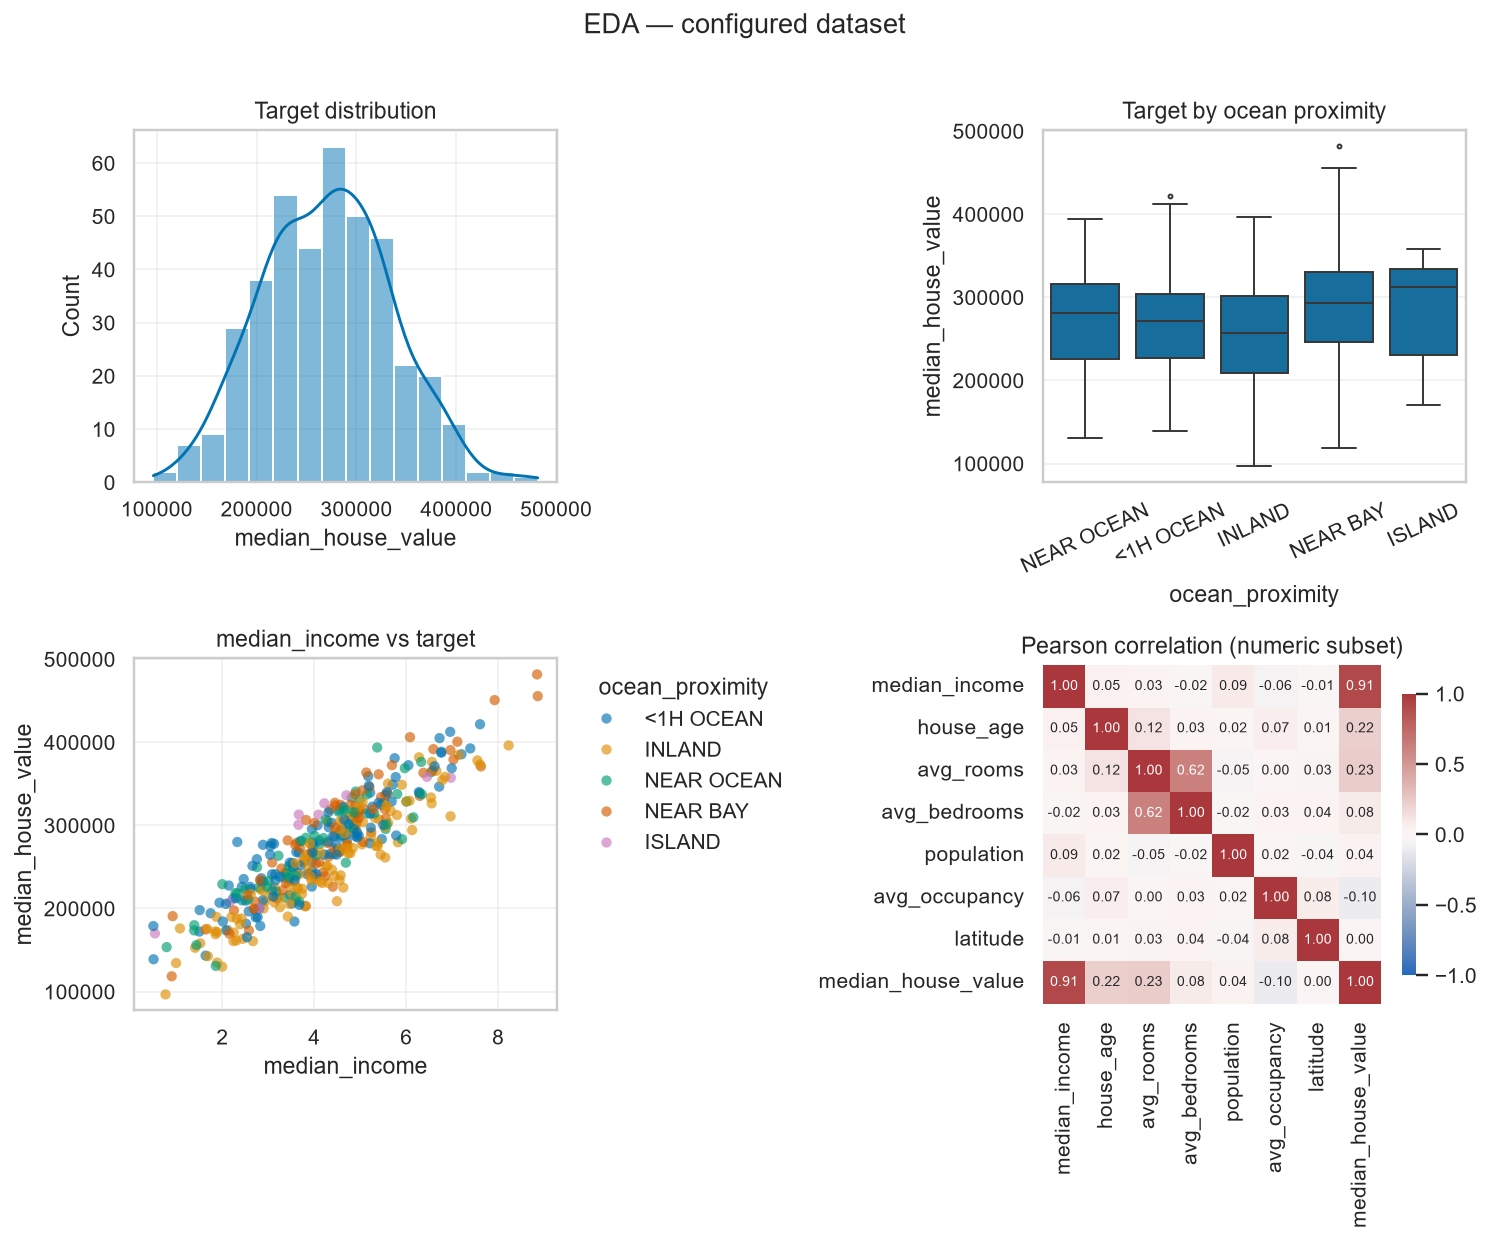

In [13]:
num_df = df_model.select_dtypes(include=[np.number])
plot_cols = list(num_df.columns[:8])  # why: 8 columns keep the heatmap readable
if target_col not in plot_cols and target_col in num_df.columns:
    plot_cols = plot_cols[:-1] + [target_col]

_banner("4 · EDA panel", "#9a3412")
fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.8))  # why: 2×2 lab figure for the record
ax = axes.ravel()

sns.histplot(df_model[target_col], kde=True, ax=ax[0], color="C0", edgecolor="white")
ax[0].set_title("Target distribution")
ax[0].set_xlabel(target_col)

if cat_col is not None:
    sns.boxplot(data=df_model, x=cat_col, y=target_col, ax=ax[1], fliersize=2)  # why: small outliers, less ink
    ax[1].set_title("Target by ocean proximity")
    ax[1].tick_params(axis="x", rotation=25)
else:
    sns.boxplot(y=df_model[target_col], ax=ax[1], color="C1")
    ax[1].set_title("Target boxplot (no category column)")

x_sc = income_col if income_col in df_model.columns else plot_cols[0]
sns.scatterplot(
    data=df_model.sample(n=min(400, len(df_model)), random_state=SEED),  # why: cap points to reduce overplotting
    x=x_sc,
    y=target_col,
    hue=cat_col if cat_col else None,
    ax=ax[2],
    alpha=0.65,   # why: transparency shows overlapping houses
    s=28,         # why: marker size readable but not covering neighbors
    edgecolor="none",
)
ax[2].set_title(f"{x_sc} vs target")
if cat_col:
    ax[2].legend(title=cat_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

corr = num_df[plot_cols].corr(numeric_only=True)  # why: numeric_only skips leftover object cols
sns.heatmap(
    corr,
    ax=ax[3],
    cmap="vlag",   # why: diverging colormap for r in [-1, 1]
    center=0,      # why: 0 = no linear association sits in the middle
    vmin=-1,
    vmax=1,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
)
ax[3].set_title("Pearson correlation (numeric subset)")

fig.suptitle("EDA — configured dataset", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()


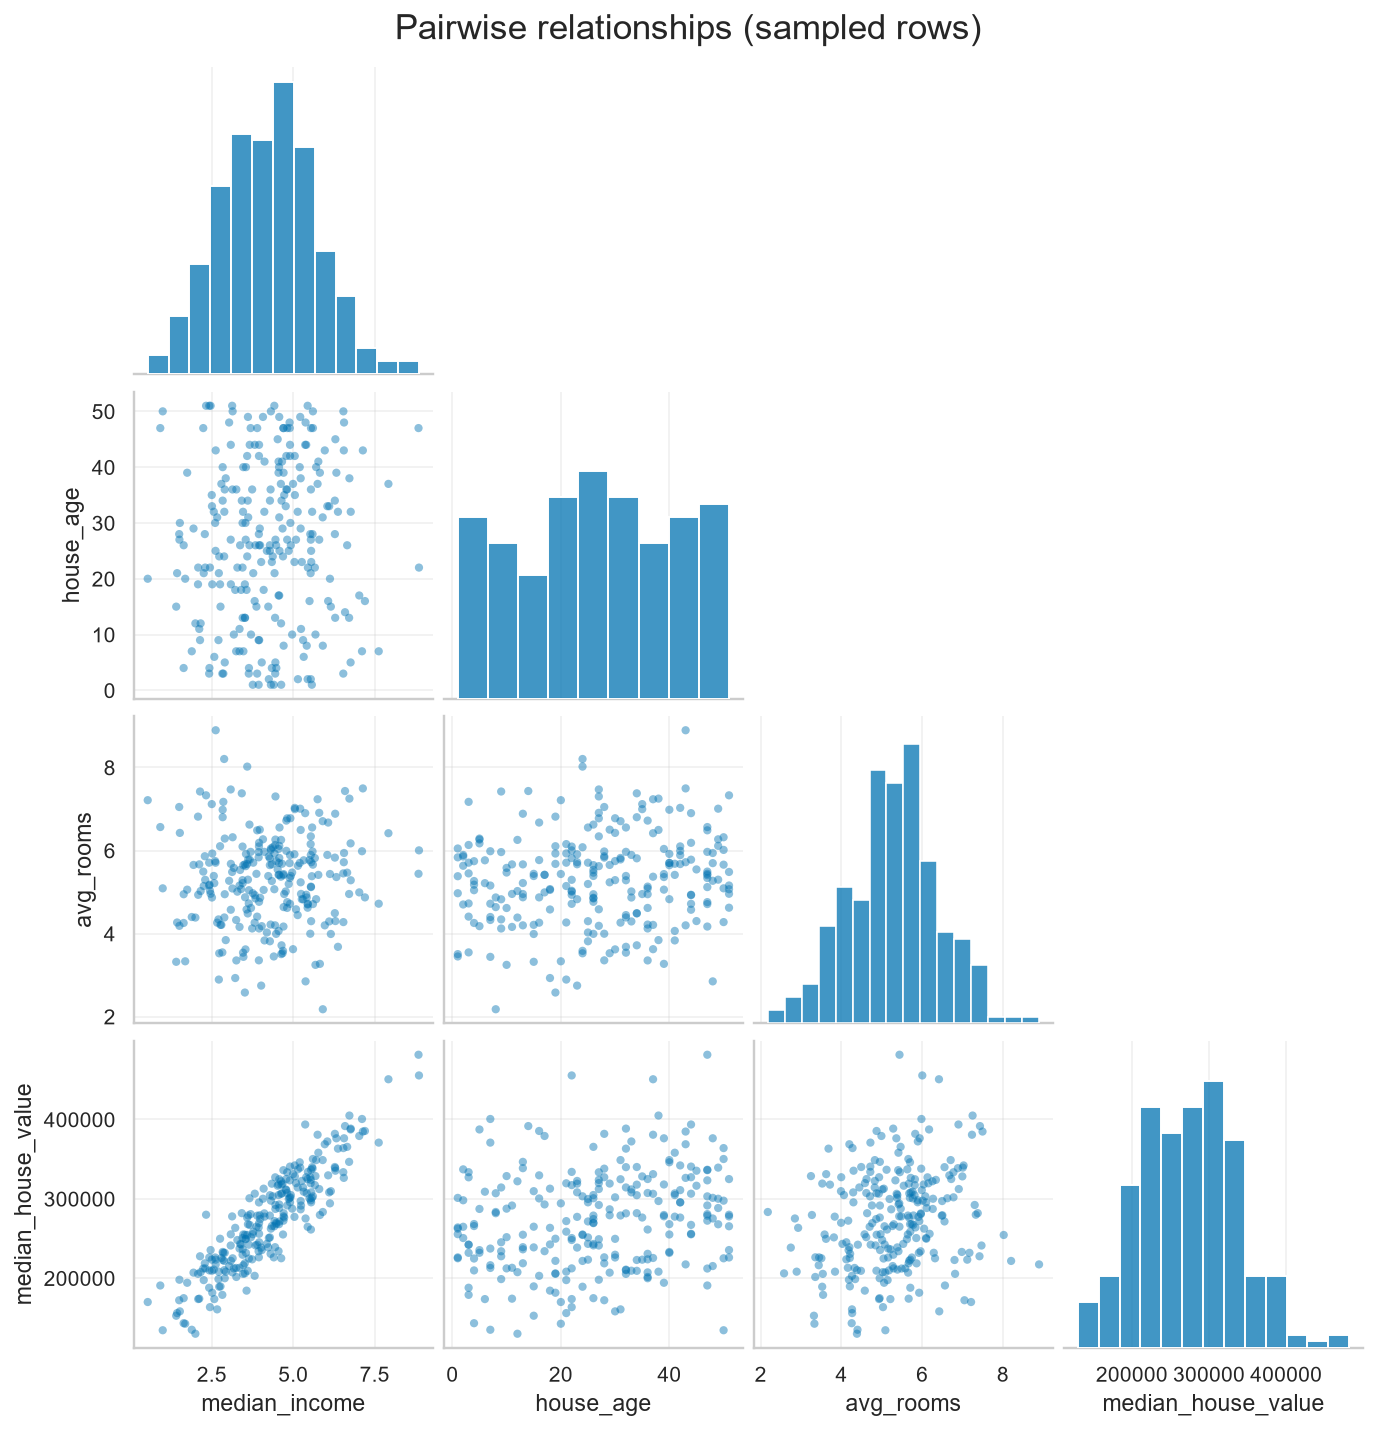

In [14]:
pair_cols = [
    c
    for c in [income_col, "house_age", "HouseAge", "avg_rooms", "AveRooms", target_col]
    if c and c in df_model.columns
]
pair_cols = list(dict.fromkeys(pair_cols))[:4]  # why: pairplot is O(p²) panels — keep p small
_banner("4 · Pairplot", "#c2410c")
if len(pair_cols) >= 2:
    g = sns.pairplot(
        df_model[pair_cols].sample(n=min(250, len(df_model)), random_state=SEED),
        corner=True,          # why: skip duplicate upper triangle
        diag_kind="hist",
        plot_kws={"alpha": 0.45, "s": 18, "edgecolor": "none"},
    )
    g.fig.suptitle("Pairwise relationships (sampled rows)", y=1.02)
    plt.show()
else:
    print("Not enough overlapping columns for pairplot on this load origin.")


## 5. scikit-learn baseline — split, scale, fit, evaluate

### 5.1 Leakage rules (read this twice)

```text
WRONG:  scale ALL rows using everyone' s mean/std  →  then split
        (test information leaked into the features)

RIGHT:  split first
        fit imputer + scaler on TRAIN only
        transform TEST with those frozen numbers
```

`StandardScaler.fit` uses

$$
\mu_j^{\mathrm{train}} = \frac{1}{n_{\mathrm{train}}} \sum_{i \in \mathrm{train}} X_{ij}, \quad
\sigma_j^{\mathrm{train}} = \sqrt{\frac{1}{n_{\mathrm{train}}}\sum_{i\in\mathrm{train}}(X_{ij}-\mu_j)^2}
$$

Apply $\mu^{\mathrm{train}}, \sigma^{\mathrm{train}}$ to the **test** set (`transform` only).

> **Why this matters:** fitting the scaler on all data **leaks** hold-out information and makes test scores look too good.


In [15]:
feature_cols = [c for c in df_model.select_dtypes(include=[np.number]).columns if c != target_col]
X = df_model[feature_cols].to_numpy(dtype=np.float64)  # why: sklearn expects a numeric ndarray
y = df_model[target_col].to_numpy(dtype=np.float64)

_banner("5.1 · Design matrix", "#166534")
print("features:", feature_cols)
print("X shape", X.shape, "y shape", y.shape)


features: ['median_income', 'house_age', 'avg_rooms', 'avg_bedrooms', 'population', 'avg_occupancy', 'latitude', 'longitude']
X shape (400, 8) y shape (400,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,     # why: 20% hold-out — enough to test, most rows still train
    random_state=SEED,  # why: same shuffle every re-run so lab numbers match
    shuffle=True,       # why: do not test only the last 20% of the file (order may be sorted)
)

_banner("5.2 · Split, impute, scale", "#15803d")
print(f"train n={len(y_train)} | test n={len(y_test)} | p={X_train.shape[1]}")

# --- Production path: SimpleImputer (sklearn) ---
imputer = SimpleImputer(strategy="median")  # why: median is robust to extreme houses; fit on TRAIN only
X_train_i = imputer.fit_transform(X_train)
X_test_i = imputer.transform(X_test)  # why: transform only — test must not choose its own medians

# --- Same idea with broadcasting (commented teaching copy; not used below) ---
# col_median = np.nanmedian(X_train, axis=0)          # shape (p,)
# nan_train = np.isnan(X_train)
# X_train_broadcast = np.where(nan_train, col_median, X_train)  # (n,p) vs (p,) broadcast
# X_test_broadcast = np.where(np.isnan(X_test), col_median, X_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_i)  # why: learn μ, σ from TRAIN
X_test_s = scaler.transform(X_test_i)        # why: reuse TRAIN μ, σ on TEST

stats = pd.DataFrame(
    {
        "feature": feature_cols[:8],
        "train_mean_after_scale": X_train_s.mean(axis=0)[:8],
        "train_std_after_scale": X_train_s.std(axis=0)[:8],
    }
)
display(
    stats.style.format("{:.6f}", subset=["train_mean_after_scale", "train_std_after_scale"])
    .set_caption("After StandardScaler on TRAIN: means ~ 0, stds ~ 1 (first 8 features)")
)


train n=320 | test n=80 | p=8


,feature,train_mean_after_scale,train_std_after_scale
0,median_income,0.000000,1.000000
1,house_age,0.000000,1.000000
2,avg_rooms,0.000000,1.000000
3,avg_bedrooms,-0.000000,1.000000
4,population,0.000000,1.000000
5,avg_occupancy,0.000000,1.000000
6,latitude,-0.000000,1.000000
7,longitude,-0.000000,1.000000


In [17]:
model = LinearRegression()  # why: closed-form OLS / SVD — no learning-rate to tune
model.fit(X_train_s, y_train)

y_hat_tr = model.predict(X_train_s)
y_hat_te = model.predict(X_test_s)


def regression_report(y_true: np.ndarray, y_pred: np.ndarray, split: str) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))  # why: RMSE in the same units as y (after the square root)
    return {
        "split": split,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }


_banner("5.3 · Metrics & weights", "#166534")
metrics = pd.DataFrame(
    [
        regression_report(y_train, y_hat_tr, "train"),
        regression_report(y_test, y_hat_te, "test"),
    ]
)
display(
    metrics.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.4f}"})
    .background_gradient(subset=["R2"], cmap="Greens")
    .set_caption("Hold-out metrics (test row is the one that counts)")
)
print("intercept b =", float(model.intercept_))
coef_tbl = pd.DataFrame({"feature": feature_cols, "weight": model.coef_}).sort_values(
    "weight", key=np.abs, ascending=False
)
display(
    coef_tbl.head(10)
    .style.format({"weight": "{:.4f}"})
    .bar(subset=["weight"], align="mid", color=["#fecaca", "#bbf7d0"])
    .set_caption("Largest |weights| (scaled features — magnitude = importance in this linear model)")
)


,split,MAE,RMSE,R2
0,train,17362.08,21247.04,0.8928
1,test,14664.40,19157.92,0.9017


intercept b = 270299.8568749999


,feature,weight
0,median_income,57623.1649
2,avg_rooms,12742.3845
1,house_age,11047.1026
5,avg_occupancy,-3710.3278
4,population,-3242.0118
3,avg_bedrooms,-1157.9418
7,longitude,724.8638
6,latitude,20.2729


Hold-out $R^2$:

$$
R^{2} = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

- $R^2 = 1$: perfect predictions  
- $R^2 = 0$: no better than predicting the mean of $y$  
- $R^2 < 0$: worse than that mean baseline  

If **train** $R^2$ is much larger than **test** $R^2$, the linear model is overfitting (or the split is unlucky). If both are weak, the linear story is too simple (nonlinearity, missing categoricals, need regularization — later practicals).


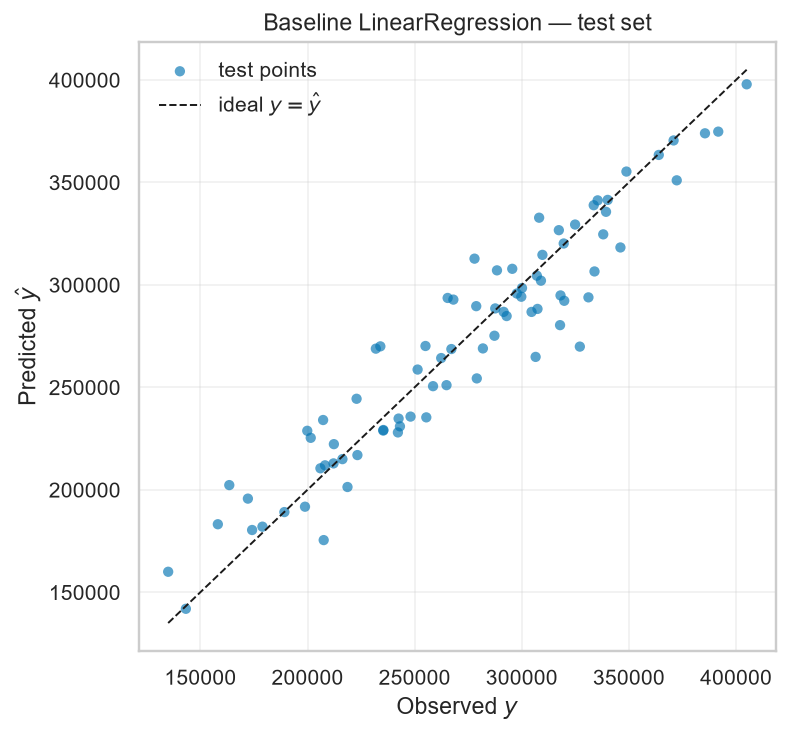

In [18]:
_banner("5.4 · Predicted vs observed", "#14532d")
fig, ax = plt.subplots(figsize=(5.8, 5.4))
ax.scatter(
    y_test,
    y_hat_te,
    alpha=0.65,  # why: see density where many houses overlap
    s=28,
    edgecolor="none",
    c="C0",
    label="test points",
)
lo = min(float(y_test.min()), float(y_hat_te.min()))
hi = max(float(y_test.max()), float(y_hat_te.max()))
ax.plot([lo, hi], [lo, hi], color="k", lw=1.0, ls="--", label=r"ideal $y=\hat{y}$")  # why: dashed line = perfect
ax.set_xlabel(r"Observed $y$")
ax.set_ylabel(r"Predicted $\hat{y}$")
ax.set_title("Baseline LinearRegression — test set")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 6. Viva-voce (indicative Q&A)

**Q1. What is vectorization, and why is a Python `for` loop over 10 million floats slow?**  
**A.** Vectorization means applying an operation to whole arrays via compiled inner loops (NumPy/BLAS). CPython loops dispatch bytecode per element. The algorithm may be the same $\Theta(n)$ additions, but the **constant factor** differs by $10\times$–$100\times$ (see the timing table).

**Q2. State the broadcasting rule for $(n, p)$ minus $(p,)$.**  
**A.** Shapes align on the right: $(n, p)$ and $(p,)$ → $(n, p)$ and $(1, p)$ virtually. Subtraction is per column.

**Q3. Write the OLS normal equations.**  
**A.** For full-rank $\Phi$, $\hat{w} = (\Phi^{\top}\Phi)^{-1}\Phi^{\top} y$, equivalently $\Phi^{\top}\Phi\,\hat{w} = \Phi^{\top} y$. Prefer `np.linalg.solve` or SVD; never form an explicit inverse in production.

**Q4. Why `StandardScaler.fit` on the training set only?**  
**A.** $\mu$ and $\sigma$ are **learned parameters**. Using the test set to compute them leaks hold-out information into $X_{\mathrm{test}}$.

**Q5. What does `train_test_split(..., random_state=42)` guarantee?**  
**A.** A deterministic shuffle given the same input arrays and sklearn version behavior. It does **not** guarantee the test set is a perfect sample of future data.

**Q6. Difference between MAE and RMSE?**  
**A.** MAE $= \frac{1}{n}\sum |y_i-\hat{y}_i|$ is linear in residuals. RMSE $= \sqrt{\frac{1}{n}\sum (y_i-\hat{y}_i)^2}$ penalizes large errors more. Units: same as $y$ for both (RMSE after the square root).

**Q7. Can a correlation heatmap prove that income *causes* house value?**  
**A.** No. $r$ is a linear association. Confounders can induce correlation. Causal claims need design beyond this lab.

**Q8. What is `ddof` in `np.std` vs sklearn’s scaler?**  
**A.** `StandardScaler` uses population std (`ddof=0`): divide by $n$. Pandas `Series.std()` defaults to sample std (`ddof=1`).

**Q9. How would you include `ocean_proximity` in the linear model?**  
**A.** One-hot encode **after** split, fitting the encoder on train categories only (`handle_unknown='ignore'`).

**Q10. What does a test $R^2$ of 0 mean?**  
**A.** The model is no better than predicting the mean of $y$ on that split. Negative $R^2$ means worse than that baseline.

**Q11. Why might local CSV metrics differ from URL/sklearn fallback?**  
**A.** Different $n$ and feature sets (lab file is a **400-row** benchmark; Géron/sklearn files are the real $\sim$20k California housing table). Always log `load_origin`.

**Q12. What is the shape of `X_train_s` after scaling?**  
**A.** Unchanged $(n_{\mathrm{train}}, p)$. Scaling is per-feature affine, not a projection (unlike PCA).

**Q13. Why `SimpleImputer` on train only?**  
**A.** The median of each feature is a learned statistic — same leakage rule as the scaler.


## 7. Conclusion

This practical established the **minimum professional loop** for tabular ML in Python:

1. **Config first:** `DATA_PATH`, `TARGET_COLUMN`, `DROP_COLUMNS` — swap a CSV without hunting through the notebook.
2. **NumPy** as the numerical machine: vectorized products (timed vs loops), broadcasting, and the OLS identity on a toy problem.
3. **Pandas** as the tabular contract: dtypes, missingness, boolean filters, and `groupby`.
4. **Seaborn/Matplotlib** as the communication layer: labeled, colorblind-safe EDA.
5. **scikit-learn:** `train_test_split` → train-only `SimpleImputer` + `StandardScaler` → `LinearRegression` → MAE / RMSE / $R^2$ on a frozen test set.

**Load path:** local `DATA_PATH` → Colab upload / Drive (`COLAB_DRIVE_CSV`) → HTTPS CSV → `fetch_california_housing`, with `load_origin` recorded.

**Next practical (planned):** leakage-safe `Pipeline` objects, categorical encoding, and systematic missing-value strategies — still without touching any files under `extra/`.

### Submission checklist

- [ ] Re-run all cells top-to-bottom  
- [ ] Record `load_origin`, Python / library versions, and `SEED`  
- [ ] If you used your own CSV: paste your three config lines in the lab record  


---

*End of Practical 01.*
